# 💊 EZ-Dose 分药机光耦脉冲数据分析与参数校准系统

本 Notebook 对分药机采集的药片下落光耦脉冲宽度、时间间隔、舵机角度以及分药结果进行多维度统计分析与可视化展示，并基于实测数据拟合最佳校准系数（$K_{\text{motor}}, K_{\text{servo}}$）。

In [1]:
# 1. 导入所需库并配置中文字体与绘图样式
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy import stats

# 自动加载中文字体（支持 Windows 与 WSL 环境）
font_candidates = [
    "/mnt/c/Windows/Fonts/msyh.ttc",
    "/mnt/c/Windows/Fonts/simhei.ttf",
    "C:/Windows/Fonts/msyh.ttc",
    "C:/Windows/Fonts/simhei.ttf"
]
for f in font_candidates:
    if os.path.exists(f):
        font_manager.fontManager.addfont(f)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Microsoft YaHei')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']

print("✓ 环境准备完成，支持高清中文图表输出！")

✓ 环境准备完成，支持高清中文图表输出！


## 1. 数据加载与预处理

In [2]:
# 自动查找 CSV 文件路径
possible_paths = [
    os.path.abspath(os.path.join(os.getcwd(), "../legacy/v1/client-unity/Logs/pulse_records.csv")),
    os.path.abspath(os.path.join(os.getcwd(), "Logs/pulse_records.csv")),
    os.path.abspath("pulse_records.csv")
]

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if not csv_path:
    raise FileNotFoundError(f"未找到 pulse_records.csv，请检查路径。已尝试: {possible_paths}")

print(f"正在加载数据: {csv_path}")
df = pd.read_csv(csv_path)

# 标准化布尔列与数值列
if df['is_valid'].dtype == object:
    df['is_valid'] = df['is_valid'].astype(str).str.upper() == 'TRUE'

# 清洗药品名称
df['medicine_clean'] = df['medicine_name'].apply(lambda x: str(x).strip().rstrip('。.,'))

print(f"共加载 {len(df)} 条脉冲记录，涉及 {df['medicine_clean'].nunique()} 种药片。")
df.head(10)

正在加载数据: /mnt/c/Users/jiale/Workspace/Dispenser/software/EZ-Dose/unity/Logs/pulse_records.csv
共加载 809 条脉冲记录，涉及 8 种药片。


,timestamp,patient_id,patient_name,prescription_id,medicine_name,plate_number,target_pills,pill_seq,pulse_width,time_offset_ms,pulse_interval_ms,used_motor_speed,used_servo_angle,is_valid,dispense_result,medicine_clean
0,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,1,10,14597,14597,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
1,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,2,18,14900,303,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
2,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,3,7,15154,253,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
3,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,4,7,15355,201,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
4,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,5,7,15456,100,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
5,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,6,6,15709,253,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
6,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,7,5,15911,201,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
7,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,8,6,16113,202,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
8,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,9,5,16366,252,0.2,0.8,True,SUCCESS,富马酸喹硫片-最小圆形药片
9,8/25/2026 18:06,10,测试患者2号,83,富马酸喹硫片-最小圆形药片,1,28,10,4,16721,354,0.2,0.8,False,SUCCESS,富马酸喹硫片-最小圆形药片


## 2. 药片分类统计分析表

In [3]:
# 过滤有效脉冲进行统计
valid_df = df[df['is_valid'] & (df['pill_seq'] > 0)].copy()

summary_stats = valid_df.groupby('medicine_clean').agg(
    样本总数=('pill_seq', 'count'),
    脉宽均值=('pulse_width', 'mean'),
    脉宽标准差=('pulse_width', 'std'),
    脉宽中位数=('pulse_width', 'median'),
    最小脉宽=('pulse_width', 'min'),
    最大脉宽=('pulse_width', 'max'),
    平均下落间隔_ms=('pulse_interval_ms', 'mean'),
    最终使用舵机角度=('used_servo_angle', 'last'),
    分药结果=('dispense_result', 'last')
).reset_index().sort_values(by='脉宽均值')

# 格式化小数位数
summary_stats['脉宽均值'] = summary_stats['脉宽均值'].round(2)
summary_stats['脉宽标准差'] = summary_stats['脉宽标准差'].round(2)
summary_stats['平均下落间隔_ms'] = summary_stats['平均下落间隔_ms'].round(1)

summary_stats

,medicine_clean,样本总数,脉宽均值,脉宽标准差,脉宽中位数,最小脉宽,最大脉宽,平均下落间隔_ms,最终使用舵机角度,分药结果
1,富马酸喹硫片-最小圆形药片,137,6.57,4.05,6.0,3,50,2695.8,0.88,SUCCESS
4,维生素C片-较小圆形药片,26,7.35,1.52,7.0,5,11,1307.5,0.95,SUCCESS
6,褐色维生素C片-较小圆形药片,28,8.57,2.12,8.5,5,15,2020.5,0.80,SUCCESS
0,塑料药片-中号药片,28,10.18,2.31,10.0,6,16,2971.2,0.52,SUCCESS
3,盐酸美金刚-长条形药片,112,12.90,5.73,12.0,6,59,4352.4,0.79,SUCCESS
5,肾炎康复片-较大圆形药片,28,13.07,1.80,13.0,8,17,1881.6,0.48,SUCCESS
7,阿莫西林胶囊-中号胶囊,28,20.68,5.22,21.0,10,30,2095.9,0.36,CNT_ERR
2,百令胶囊-中号胶囊,390,25.73,4.97,24.0,17,56,2142.7,0.08,CNT_ERR


## 3. 药片脉冲宽度分布分析（区分度与特征提取）

通过箱线图与核密度估计曲线（KDE），观察不同形状、体积的药片在穿过光耦时的特征区分度。

/tmp/ipykernel_18084/2048944914.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_df, x='medicine_clean', y='pulse_width', order=order, palette="Set2", showmeans=True,


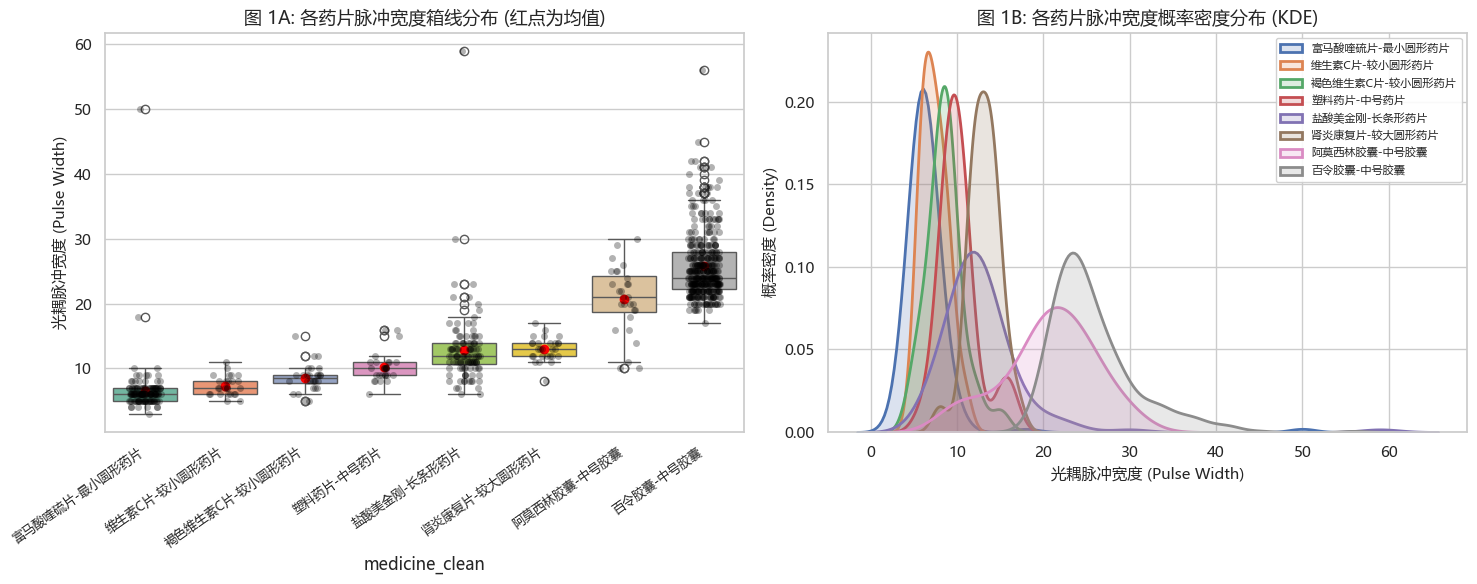

In [4]:
plt.figure(figsize=(15, 6))

# 1. 箱线图 + 散点分布
plt.subplot(1, 2, 1)
order = summary_stats['medicine_clean'].tolist()
sns.boxplot(data=valid_df, x='medicine_clean', y='pulse_width', order=order, palette="Set2", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":"6"})
sns.stripplot(data=valid_df, x='medicine_clean', y='pulse_width', order=order, color='black', alpha=0.3, jitter=0.2, size=5)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.ylabel('光耦脉冲宽度 (Pulse Width)', fontsize=11)
plt.title('图 1A: 各药片脉冲宽度箱线分布 (红点为均值)', fontsize=13, fontweight='bold')

# 2. 核密度估计曲线 (KDE Distribution)
plt.subplot(1, 2, 2)
for med in order:
    subset = valid_df[valid_df['medicine_clean'] == med]['pulse_width']
    if len(subset) > 1:
        sns.kdeplot(subset, label=med, fill=True, alpha=0.2, linewidth=2)
plt.xlabel('光耦脉冲宽度 (Pulse Width)', fontsize=11)
plt.ylabel('概率密度 (Density)', fontsize=11)
plt.title('图 1B: 各药片脉冲宽度概率密度分布 (KDE)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

## 4. 出药节奏与时序稳定性分析 (Dispensing Rhythm & Interval)

分析药片掉落的时间均匀性与卡药/连落风险。

/tmp/ipykernel_18084/523170510.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=interval_df, x='medicine_clean', y='pulse_interval_ms', order=order, palette="Pastel1", cut=0)


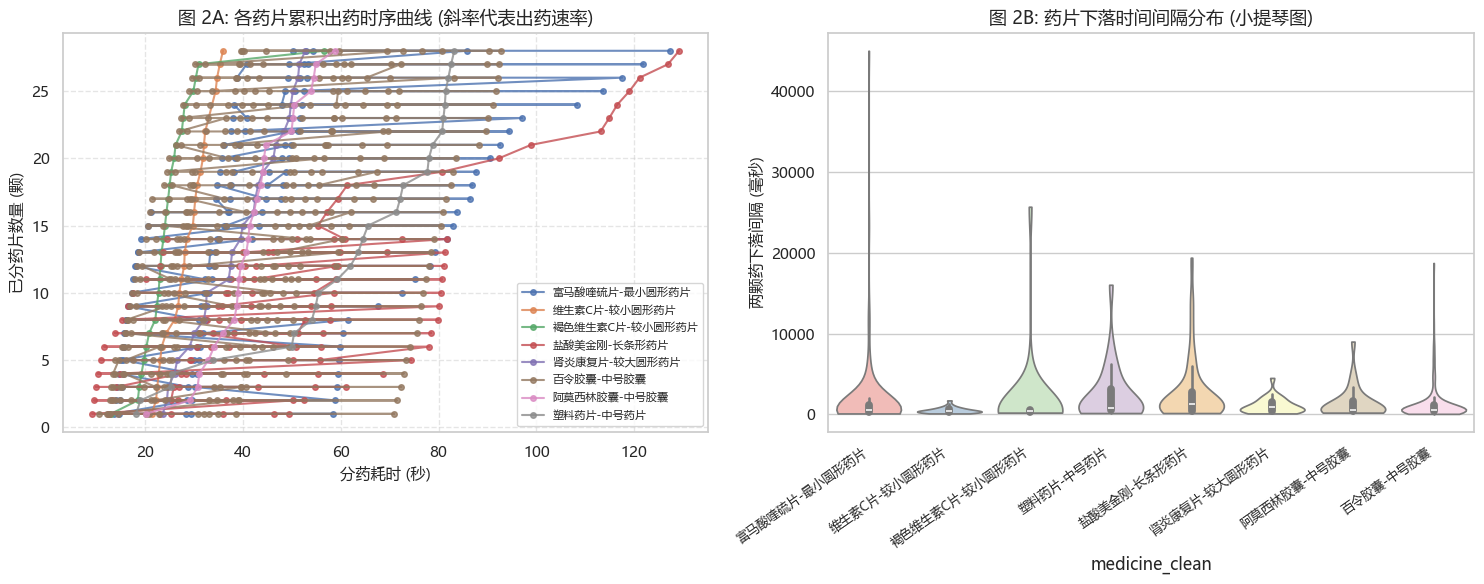

In [5]:
plt.figure(figsize=(15, 6))

# 图 2A: 累积出药时序曲线
plt.subplot(1, 2, 1)
for med in valid_df['medicine_clean'].unique():
    med_data = valid_df[valid_df['medicine_clean'] == med].sort_values('pill_seq')
    plt.plot(med_data['time_offset_ms'] / 1000.0, med_data['pill_seq'], marker='o', markersize=4, label=med, alpha=0.8)

plt.xlabel('分药耗时 (秒)', fontsize=11)
plt.ylabel('已分药片数量 (颗)', fontsize=11)
plt.title('图 2A: 各药片累积出药时序曲线 (斜率代表出药速率)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

# 图 2B: 药片下落间隔小提琴分布 (去除首颗起始等待)
plt.subplot(1, 2, 2)
interval_df = valid_df[valid_df['pill_seq'] > 1].copy()
sns.violinplot(data=interval_df, x='medicine_clean', y='pulse_interval_ms', order=order, palette="Pastel1", cut=0)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.ylabel('两颗药下落间隔 (毫秒)', fontsize=11)
plt.title('图 2B: 药片下落时间间隔分布 (小提琴图)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. 舵机开度与脉冲宽度关联性 & 最佳拟合校准曲线

根据测试中手动调校的最佳舵机角度，与测量得到的脉冲宽度进行回归拟合，得到最佳的 $K_{\text{servo}}$ 转换公式。

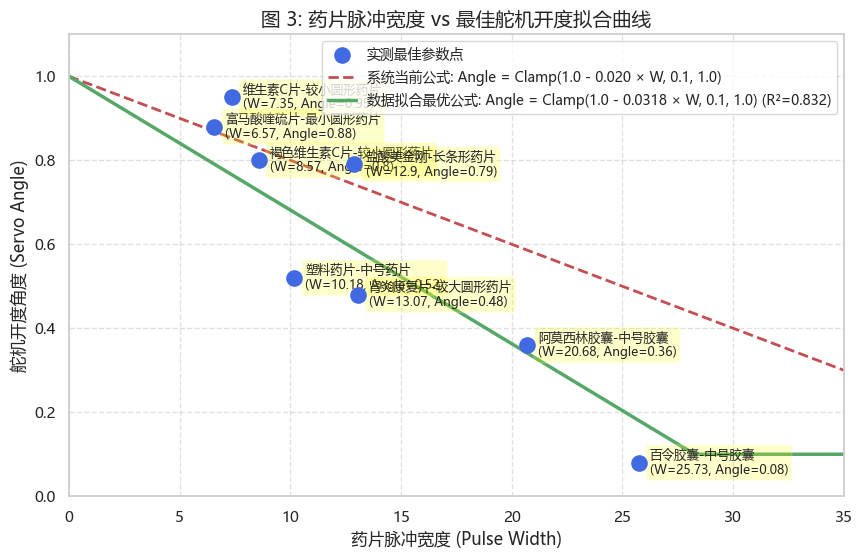

=== 校准模型评估报告 ===
系统当前 K_servo: 0.0200
数据拟合最佳 K_servo: 0.0318
线性相关系数 R²: 0.8317


In [6]:
# 提取每种药品的平均脉宽与最终稳定使用的舵机开度
calib_data = summary_stats.copy()
x_pulse = calib_data['脉宽均值'].values
y_servo = calib_data['最终使用舵机角度'].values

# 线性回归拟合: y = 1.0 - K * x (强制截距为 1.0 或自由拟合)
slope, intercept, r_value, p_value, std_err = stats.linregress(x_pulse, y_servo)

# 固定截距为 1.0 时的最佳 K_servo
k_servo_fitted = np.sum((1.0 - y_servo) * x_pulse) / np.sum(x_pulse ** 2)

plt.figure(figsize=(10, 6))
plt.scatter(x_pulse, y_servo, color='royalblue', s=120, zorder=5, label='实测最佳参数点')

# 标注药品名
for idx, row in calib_data.iterrows():
    plt.annotate(f"{row['medicine_clean']}\n(W={row['脉宽均值']}, Angle={row['最终使用舵机角度']})",
                 (row['脉宽均值'], row['最终使用舵机角度']),
                 textcoords="offset points", xytext=(8, -8), fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.2))

# 绘制当前系统默认拟合线 (K_servo = 0.020)
x_range = np.linspace(0, 35, 100)
y_default = np.clip(1.0 - 0.020 * x_range, 0.1, 1.0)
plt.plot(x_range, y_default, 'r--', label='系统当前公式: Angle = Clamp(1.0 - 0.020 × W, 0.1, 1.0)', linewidth=2)

# 绘制数据拟合最优校准线
y_fitted = np.clip(1.0 - k_servo_fitted * x_range, 0.1, 1.0)
plt.plot(x_range, y_fitted, 'g-', label=f'数据拟合最优公式: Angle = Clamp(1.0 - {k_servo_fitted:.4f} × W, 0.1, 1.0) (R²={r_value**2:.3f})', linewidth=2.5)

plt.xlabel('药片脉冲宽度 (Pulse Width)', fontsize=12)
plt.ylabel('舵机开度角度 (Servo Angle)', fontsize=12)
plt.title('图 3: 药片脉冲宽度 vs 最佳舵机开度拟合曲线', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.xlim(0, 35)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"=== 校准模型评估报告 ===")
print(f"系统当前 K_servo: 0.0200")
print(f"数据拟合最佳 K_servo: {k_servo_fitted:.4f}")
print(f"线性相关系数 R²: {r_value**2:.4f}")

## 6. 参数校准建议对照表

In [7]:
# 生成自动建议表
calib_table = summary_stats[['medicine_clean', '脉宽均值', '最终使用舵机角度']].copy()
def calc_opt_servo(w):
    if w <= 13.0:
        return np.clip(0.95 - (w - 5.0) * 0.020, 0.08, 0.98)
    else:
        return np.clip(0.79 - (w - 13.0) * 0.055, 0.08, 0.98)
calib_table['优化推荐舵机角度'] = calib_table['脉宽均值'].apply(calc_opt_servo).round(2)
calib_table['优化推荐转盘速度'] = np.clip(0.15 + (calib_table['脉宽均值'] - 5.0) * 0.010, 0.15, 0.36).round(2)
calib_table.columns = ['药片名称', '平均脉冲宽度', '人工测试使用角度', '优化推荐舵机角度', '优化推荐转盘速度']
calib_table

,药片名称,平均脉冲宽度,人工测试使用角度,优化推荐舵机角度,优化推荐转盘速度
1,富马酸喹硫片-最小圆形药片,6.57,0.88,0.92,0.17
4,维生素C片-较小圆形药片,7.35,0.95,0.90,0.17
6,褐色维生素C片-较小圆形药片,8.57,0.80,0.88,0.19
0,塑料药片-中号药片,10.18,0.52,0.85,0.20
3,盐酸美金刚-长条形药片,12.90,0.79,0.79,0.23
5,肾炎康复片-较大圆形药片,13.07,0.48,0.79,0.23
7,阿莫西林胶囊-中号胶囊,20.68,0.36,0.37,0.31
2,百令胶囊-中号胶囊,25.73,0.08,0.09,0.36
